In [130]:
import matplotlib.pyplot as plt

import sys

sys.path.append('../../')
import src.forecasting.models      as fm
import src.forecasting.pipelines   as fp
import src.forecasting.simulations as fsim
from itertools import product
import src.fda.kde.estimators           as kde
import src.fda.transformations.lqdt     as lqdt

In [ ]:
# Define scenarios
gas_params = {
    "scenario_4": {
        "Description": "Mixture",
        "alpha": np.diag([0.04, 0.06, 0.04]),
        "beta": np.diag([0.92, 0.95, 0.94]),
    }
}

distribution_params = {
    "nu": [3]
}

keys = ["scenario", "nu"]
values = [list(gas_params.keys()), distribution_params["nu"]]

param_grid = []

for scenario, nu in product(*values):
    gas_cfg = gas_params[scenario]

    param_grid.append({
        "scenario": "___nu=".join([scenario, str(nu)]),
        "nu": nu,
        "alpha": gas_cfg["alpha"],
        "beta": gas_cfg["beta"]    
})
    
# grid for densities
x = np.linspace(-40, 40, 5001)
# number of curves (densities)
T = 301
# number of simulations (f_{N_REP,1},...,f_{N_REP,T})
N_REPS = 10
# number of samples from each f_t density
N_SAMPLES = 288

total = len(param_grid) * N_REPS

sim_database = {}
total = len(param_grid) * N_REPS

for params in param_grid:
    scenario = params["scenario"]
    # Initialize scenario level
    sim_database[scenario] = {
        "params": params,
        "replications": {}
    }
    
    for n_rep in range(N_REPS):
        # 1. Setup Model and Simulate
        gm = fsim.GasModel(alpha=params["alpha"], beta=params["beta"], nu=params["nu"])
        sim_results = gm.simulate(T=T, burn_in=300)
        
        # 2. Get Theoretical Densities
        sim_density = gm.conditional_densities(grid=x, theta_path=sim_results["theta"])
        dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=T, freq="D")
        sim_density.columns = dates
        
        # 3. Generate Samples Efficiently
        # Collect arrays first, then create DataFrame once
        samples_list = []
        for i in range(len(sim_results["theta"])):
            # Draw n samples for the theta at time i
            sample = gm.rvs(n=N_SAMPLES, theta=sim_results["theta"][i])
            samples_list.append(sample)
        
        # Create DataFrame: each column is a time step, each row a sample
        df_samples = pd.DataFrame(np.array(samples_list).T, columns=dates)
        
        # 4. Store in Database
        sim_database[scenario]["replications"][n_rep] = {
            "theta": sim_results["theta"],
            "densities": sim_density,
            "samples": df_samples
        }

returns_df = sim_database['scenario_4___nu=3']['replications'][0]['samples']
# bandwidths
kde_bw_params = {"method": "rot", "kernel": "gaussian", "sigma_robust":False}

df_h = kde.df_bandwidth_selector(returns_df, **kde_bw_params)    
kde_params = {k: v for k, v in kde_bw_params.items() if k in ['kernel', 'df']}

# kdes
df_grids, df_densities = kde.df_to_kde(
    X=returns_df, 
    h=df_h, 
    normalize_densities=False,
    **kde_params
)

In [121]:

import numpy as np
import pandas as pd
from scipy.optimize import minimize

# Assumes these are available in your project
# from your_ast_module import StandardizedSkewStudentT
# from your_forecasting_module import run_multivariate_forecaster


class ASTParameterEstimator:
    """
    Daily MLE estimator for the standardized Fernández-Steel skew-t model.

    State vector:
        theta = (mu, log_sigma, log_a)

    where
        sigma = exp(log_sigma)
        a     = exp(log_a)
    """

    def __init__(self, nu=8):
        self.nu = nu

    def _negative_loglikelihood(self, theta, z):

        mu = theta[0]
        sigma = np.exp(theta[1])
        a = np.exp(theta[2])

        dist = fsim.StandardizedSkewStudentT(
            a=a,
            nu=self.nu
        )

        x = (z - mu) / sigma

        loglik = np.sum(
            -np.log(sigma)
            + dist.density(x, log=True)
        )

        return -loglik

    def fit_day(self, z, x0=None):

        z = np.asarray(z)

        if x0 is None:
            x0 = np.array([
                np.mean(z),
                np.log(np.std(z)),
                0.0
            ])

        res = minimize(
            self._negative_loglikelihood,
            x0=x0,
            args=(z,),
            method="L-BFGS-B"
        )

        return res.x

    def fit(self, samples: pd.DataFrame):

        params = []

        x0 = None

        for col in samples.columns:

            z = samples[col].dropna().values

            theta = self.fit_day(
                z=z,
                x0=x0
            )

            params.append(theta)

            x0 = theta.copy()

        params = pd.DataFrame(
            params,
            columns=[
                "mu",
                "log_sigma",
                "log_a"
            ],
            index=samples.columns
        )

        return params


class ParametricDensityForecaster:
    """
    Parametric benchmark based on daily MLE estimation of an
    asymmetric Student-t distribution followed by VAR forecasting.
    """

    def __init__(
        self,
        nu=3,
        maxlags=10,
        criteria="bic"
    ):

        self.nu = nu
        self.maxlags = maxlags
        self.criteria = criteria

        self.model_estimator = None
        self.parameter_history = None

    def fit(
        self,
        samples: pd.DataFrame
    ):

        self.model_estimator = ASTParameterEstimator(
            nu=self.nu
        )

        self.parameter_history = self.model_estimator.fit(
            samples
        )

        return self

    def predict(
        self,
        horizon,
        support,
        var_lags=None,
        forecast_index=None
    ):
        # --------------------------------------------------
        # Build forecast dates
        # --------------------------------------------------

        if forecast_index is not None:

            if len(forecast_index) != horizon:
                raise ValueError(
                    f"forecast_index length ({len(forecast_index)}) "
                    f"must match horizon ({horizon})"
                )

            future_dates = forecast_index

        elif (
            hasattr(self, "index_freq")
            and self.index_freq is not None
            and self.last_date is not None
        ):

            future_dates = pd.date_range(
                start=self.last_date,
                periods=horizon + 1,
                freq=self.index_freq
            )[1:]

        else:

            future_dates = np.arange(horizon)


        theta_fc = fp.run_multivariate_forecaster(

            scores=self.parameter_history.values,

            maxlags_=self.maxlags,

            criteria_=self.criteria,

            h_=horizon,

            selected_nlags=var_lags

        )

        mu_fc = theta_fc[0]
        sigma_fc = np.exp(theta_fc[1])
        a_fc = np.exp(theta_fc[2])

        density_list = []
        support_list = []

        for h in range(horizon):

            dist = fsim.StandardizedSkewStudentT(
                a=a_fc[h],
                nu=self.nu
            )

            x = (support - mu_fc[h]) / sigma_fc[h]

            density = dist.density(x) / sigma_fc[h]

            density_list.append(density)
            support_list.append(support)

        future_densities = pd.DataFrame(
            np.asarray(density_list).T, index=support_list[0].values, columns=future_dates
        )

        future_supports = pd.DataFrame(
            np.asarray(support_list).T, columns=future_dates
        )

        future_parameters = pd.DataFrame({
            "mu": mu_fc,
            "sigma": sigma_fc,
            "a": a_fc
        })

        mlqdt = lqdt.mLQDT()
        self.model_lqd = mlqdt.transform(
            densities=future_densities,
            densities_supports=future_supports, 
            verbose=False
            )
        lqd_values  = self.model_lqd.lqd.values
        lqd_support = self.model_lqd.lqd_support
        lqd_forecast = pd.DataFrame(lqd_values, index=lqd_support, columns=future_dates)

        return {

            "future_parameters": future_parameters,

            "future_densities": future_densities,

            "future_L2_curves": lqd_forecast,

            "supp": support_list

        }

In [122]:
returns_df

,2025-08-25,2025-08-26,2025-08-27,2025-08-28,2025-08-29,2025-08-30,2025-08-31,2025-09-01,2025-09-02,2025-09-03,...,2026-06-12,2026-06-13,2026-06-14,2026-06-15,2026-06-16,2026-06-17,2026-06-18,2026-06-19,2026-06-20,2026-06-21
0,0.171273,0.100161,0.376151,0.218414,0.186161,-0.235925,0.507676,-1.074567,-0.305481,0.339075,...,-1.329369,1.676358,-0.075708,0.366299,-1.231904,0.466357,1.059234,-0.882972,-1.033327,1.596431
1,0.655065,0.200526,0.476000,-0.630063,1.115882,0.396360,0.307493,-0.847420,-0.083346,1.144480,...,0.922351,-0.267565,1.037274,0.744994,0.607027,0.248807,-2.861327,1.482613,-0.161176,0.334461
2,-1.059534,0.229880,0.105207,-0.208460,-1.141983,-0.084747,-0.715942,-0.261096,-0.384255,0.194538,...,1.277839,0.406929,0.426993,-0.020038,-1.148121,0.175941,-0.757124,0.976083,1.054631,1.016929
3,0.211409,-0.443986,-0.111930,-0.417035,-0.608573,-0.046384,-0.688810,0.604933,0.233140,0.160284,...,-1.209167,-0.012993,0.367059,0.513145,1.245293,1.239171,2.511832,1.367985,-0.405012,-0.726138
4,0.267365,0.768878,-0.167052,-0.130354,-0.214570,-0.764846,0.374128,-0.239307,0.112524,-0.892574,...,-0.107252,-1.366719,-0.956409,0.156060,0.361982,1.897261,0.044289,-0.334751,0.158694,0.151386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,-0.130672,-0.277379,0.062991,1.005079,0.812112,1.400457,1.264694,0.752857,0.753105,-0.108158,...,0.306637,0.978626,-0.456476,0.775816,-0.273209,0.191503,-0.257512,1.349358,-0.006742,-0.191895
284,-1.544385,0.192296,0.287700,0.124497,0.129156,1.167680,0.453149,0.280068,0.104803,0.475355,...,0.164276,-0.133788,0.002684,0.564814,0.149886,0.038955,0.138027,0.507978,-0.836483,0.017064
285,-0.212573,0.512290,-0.973196,0.654429,0.217058,0.343866,0.425059,0.512049,-1.749166,0.108041,...,-0.040388,0.205200,-0.040346,0.550473,0.181193,-0.355502,-1.905979,0.095959,-1.910165,-0.267841
286,-0.272285,0.781853,-0.055737,-0.619807,-6.718723,-0.411030,0.761352,-0.863557,0.065292,-0.289601,...,-2.013693,0.644413,-3.109440,1.269394,0.304404,0.106693,0.906803,0.452759,0.091269,-0.019642


In [123]:
returns_train, returns_test = returns_df.iloc[:,:-1], returns_df.iloc[:,-1:] 
df_densities_train, df_densities_test = df_densities.iloc[:,:-1], df_densities.iloc[:,-1:] 
df_grids_train, df_grids_test = df_grids.iloc[:,:-1], df_grids.iloc[:,-1:] 

In [124]:
model = ParametricDensityForecaster()

In [125]:
model.fit(returns_train)

In [126]:
model.parameter_history

,mu,log_sigma,log_a
2025-08-25,-0.008723,-0.125880,0.011133
2025-08-26,0.042769,-0.232743,0.234419
2025-08-27,-0.074150,-0.263347,-0.068241
2025-08-28,0.076178,0.023005,0.109676
2025-08-29,0.019073,-0.185943,0.037379
...,...,...,...
2026-06-16,0.188720,-0.015393,0.102740
2026-06-17,0.090907,0.160922,0.175068
2026-06-18,0.100233,0.201915,0.003096
2026-06-19,0.182385,0.102759,0.033958


In [127]:
results = model.predict(1, support=df_grids.iloc[:,0], forecast_index=returns_test.columns)

<Axes: >

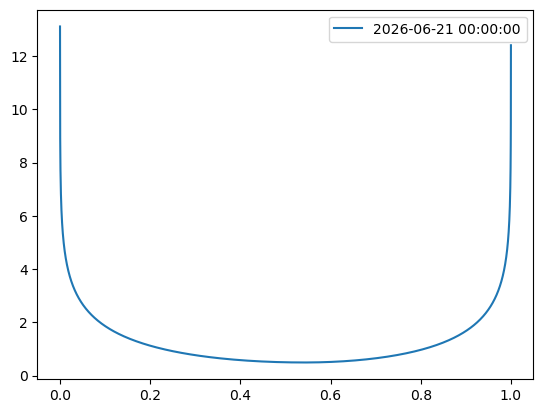

In [134]:
results["future_L2_curves"].plot()

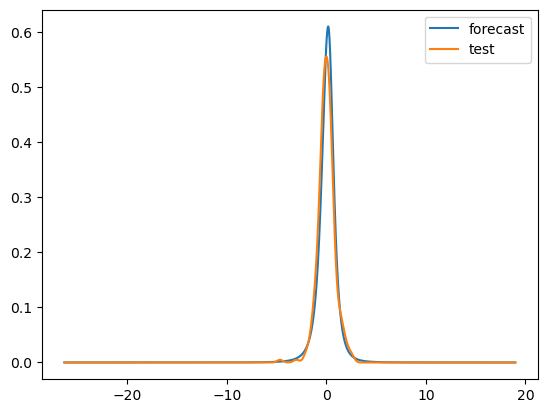

In [131]:
results["future_densities"].iloc[:,0].plot(label="forecast")
df_densities_test.iloc[:,0].plot(label="test")
plt.legend()